In [30]:
import os
import re
import torch 
import pandas as pd
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import torch.optim as optim
from scipy.signal import welch
from scipy.stats import entropy, skew, kurtosis
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
import pickle

In [31]:
# Analyzing dataset
dataset = "./all_zip/all"
dataset_actions = {}

for root, dirs, files in os.walk(dataset):
    for file in files:
        file = file[:-4]
        action =  re.sub(r'\d+$', '', file)
        if action not in dataset_actions:
            dataset_actions[action] = 1
        else:
            dataset_actions[action] += 1

Dataset_actions_log = "Dataset Actions Count\n"
total = 0
for key, value in dataset_actions.items():
    total += value
    Dataset_actions_log += f"{key}: {value} | "
Dataset_actions_log += f"total: {total}"
print(Dataset_actions_log)

Dataset Actions Count
BOMB: 200 | CAPT: 200 | HULK: 200 | IDLE: 208 | IRONMAN: 200 | LOGOUT: 198 | RELOAD: 206 | SHANGCHI: 203 | SHIELD: 201 | total: 1816


In [32]:
# Read in dataset into a dataframe of 7 columns, 6 measurement columns, 1 label
# each row has 6 lists, 1 label corresponding to 1 file
dataset = "./all_zip/all"
dataset_pd = pd.DataFrame(columns=["x_acc", "y_acc", "z_acc", "x_gyro", "y_gyro", "z_gyro", "action"])

for root, dirs, files in os.walk(dataset):
    for file in files:
        file_path = os.path.join(root, file)
        file_pd = pd.read_csv(file_path)
        x_acc = file_pd.iloc[:, 0].tolist()
        y_acc = file_pd.iloc[:, 1].tolist()
        z_acc = file_pd.iloc[:, 2].tolist()
        x_gyro = file_pd.iloc[:, 3].tolist()
        y_gyro = file_pd.iloc[:, 4].tolist()
        z_gyro = file_pd.iloc[:, 5].tolist()
        file = file[:-4]
        action =  re.sub(r'\d+$', '', file)
        row = {"x_acc": x_acc, "y_acc": y_acc, "z_acc": z_acc, "x_gyro": x_gyro, "y_gyro": y_gyro, "z_gyro": z_gyro, "action": action}
        dataset_pd = pd.concat([dataset_pd, pd.DataFrame([row])], ignore_index=True)

In [33]:
print(dataset_pd.shape)
dataset_pd.to_csv("full.csv")

(1816, 7)


In [71]:
max_time = 0

all_features = pd.DataFrame()
for i in range(len(dataset_pd.index)):
    data_dict = {}
    label = dataset_pd.iloc[i, len(dataset_pd.columns)-1]
    for j in range(len(dataset_pd.columns)-1):
        col_name = dataset_pd.columns[j]
        data = dataset_pd.iloc[i, j]
        # Compute time-domain features
        t_mean = np.mean(data)
        t_std_deviation = np.std(data)
        t_rms = np.sqrt(np.mean(np.square(data)))
        t_skew = skew(data)
        t_kurtosis = kurtosis(data)
        #t_25_q = np.percentile(data, 25)
        t_50_q = np.percentile(data, 50)
        #t_75_q = np.percentile(data, 75)

        # Compute frequency-domain features
        freq_domain = np.fft.rfft(data)
        f_mean = abs(np.mean(freq_domain))
        f_max = abs(max(freq_domain))
        f_total_power = np.sum(np.abs(freq_domain) ** 2)
        #f_average_E_per_coeff = f_total_power / len(freq_domain)

        # Create dictionary
        data_dict.update({
            f"t_mean_{col_name}": t_mean,
            f"t_std_deviation_{col_name}": t_std_deviation,
            f"t_rms_{col_name}": t_rms,
            f"t_skew_{col_name}": t_skew,
            f"t_50_q_{col_name}": t_50_q,
            f"t_kurtosis_{col_name}": t_kurtosis,
            f"f_mean_{col_name}": f_mean,
            f"f_max_{col_name}": f_max,
            f"f_total_power_{col_name}": f_total_power,
        })
    data_dict.update({f"label": label})
    
    all_features = pd.concat([all_features, pd.DataFrame([data_dict])], ignore_index=True)

all_features.to_csv("extracted_feature_with_label.csv", index=False)

label_encoder = LabelEncoder()
#all_features['label'] = label_encoder.fit_transform(all_features['label'])
#for label, encoded_label in zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)):
#    print(f"{label}: {encoded_label}")

print(all_features.shape)

(1816, 55)


In [73]:
all_features = pd.DataFrame()
for i in range(len(dataset_pd.index)):
    data_dict = {}
    label = dataset_pd.iloc[i, len(dataset_pd.columns)-1]
    for j in range(len(dataset_pd.columns)-1):
        col_name = dataset_pd.columns[j]
        data = dataset_pd.iloc[i, j]
        # Compute time-domain features
        t_mean = np.mean(data)
        t_std_deviation = np.std(data)
        t_rms = np.sqrt(np.mean(np.square(data)))
        t_skew = skew(data)
        t_kurtosis = kurtosis(data)
        #t_25_q = np.percentile(data, 25)
        t_50_q = np.percentile(data, 50)
        #t_75_q = np.percentile(data, 75)

        # Compute frequency-domain features
        freq_domain = np.fft.rfft(data)
        f_mean = abs(np.mean(freq_domain))
        f_max = abs(max(freq_domain))
        f_total_power = np.sum(np.abs(freq_domain) ** 2)
        #f_average_E_per_coeff = f_total_power / len(freq_domain)

        # Create dictionary
        data_dict.update({
            f"t_mean_{col_name}": t_mean,
            f"t_std_deviation_{col_name}": t_std_deviation,
            f"t_rms_{col_name}": t_rms,
            f"t_skew_{col_name}": t_skew,
            f"t_50_q_{col_name}": t_50_q,
            f"t_kurtosis_{col_name}": t_kurtosis,
            f"f_mean_{col_name}": f_mean,
            f"f_max_{col_name}": f_max,
            f"f_total_power_{col_name}": f_total_power,
        })
    data_dict.update({f"label": label})
    
    all_features = pd.concat([all_features, pd.DataFrame([data_dict])], ignore_index=True)

all_features.to_csv("extracted_feature_with_label.csv", index=False)
X = all_features.drop(columns=['label'])  # Features
y = all_features['label']  # Labels


In [74]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=1244)
scaler = StandardScaler()
min_max_scaler = MinMaxScaler(feature_range=(0, 1))
X_train_scaled = scaler.fit_transform(X_train)
X_train_scaled_norm = min_max_scaler.fit_transform(X_train_scaled)

# Save the scaler and min-max scaler objects
with open('scaler.pkl', 'wb') as scaler_file:
    pickle.dump(scaler, scaler_file)

with open('min_max_scaler.pkl', 'wb') as min_max_scaler_file:
    pickle.dump(min_max_scaler, min_max_scaler_file)

# Apply the same scaling and normalization to the test features
X_test_scaled = scaler.transform(X_test)
X_test_scaled_norm = min_max_scaler.transform(X_test_scaled)

# Convert labels to numeric values using label encoder
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)
class CustomDataset(Dataset):
    def __init__(self, features, labels):
        self.features = features
        self.labels = labels

    def __len__(self):
        return len(self.features)

    def __getitem__(self, idx):
        features = torch.tensor(self.features[idx], dtype=torch.float)
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return features, label

# Create dataset instances
train_dataset = CustomDataset(X_train_scaled_norm, y_train_encoded)
test_dataset = CustomDataset(X_test_scaled_norm, y_test_encoded)
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


In [75]:
class Sample_NN(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(54, 36)  # Input layer: 6 neurons, Hidden Layer: 4 neurons
        self.dropout1 = nn.Dropout(p=0.025)  # Adding dropout with probability 0.5
        self.fc2 = nn.Linear(36, 18)  # Hidden layer: 4 neurons, Output Layer: 2 neurons
        self.dropout1 = nn.Dropout(p=0.025)  # Adding dropout with probability 0.5
        self.fc3 = nn.Linear(18, 9)


    def forward(self, x):
        m = nn.ReLU()
        x = self.fc1(x)
        x = m(x)
        x = self.dropout1(x) 
        intermediate_1 = x
        x = self.fc2(x)
        x = m(x)
        x = self.dropout1(x) 
        intermediate_2 = x
        x = self.fc3(x)
        intermediate_3 = x
        output = F.softmax(x, dim=1)  # dimension 1: softmax function applied along second dimension of the tensor
        return output, intermediate_1, intermediate_2, intermediate_3

In [57]:
class Sample_NN_dataset(Dataset):
    def __init__(self, features, labels):
        self.features = features
        self.labels = labels

    def __len__(self):
        return len(self.features)

    def __getitem__(self, idx):
        features = torch.tensor(self.features[idx], dtype=torch.float)
        label = torch.tensor(self.labels[idx], dtype=torch.long)  # Assuming labels are integers
        return features, label
# Split the data into training and test sets
train_features, test_features = train_test_split(all_features, test_size=0.25, random_state=1244)  

# Separate features and labels
train_labels = train_features.pop('label')
test_labels = test_features.pop('label')

# Scale and normalize the training features
scaler = StandardScaler()
min_max_scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(train_features)
scaled_min_max_data = min_max_scaler.fit_transform(scaled_data)
train_features_scaled_norm = pd.DataFrame(scaled_min_max_data, columns=train_features.columns)

import pickle
# Save the scaler and min-max scaler objects
with open('scaler.pkl', 'wb') as scaler_file:
    pickle.dump(scaler, scaler_file)
    print("Mean:")
    print(scaler.mean_)
    print("Standard Deviation:")
    print(scaler.scale_)


with open('min_max_scaler.pkl', 'wb') as min_max_scaler_file:
    pickle.dump(min_max_scaler, min_max_scaler_file)
print(min_max_scaler.scale_)
print("hehexd")


# Apply the same scaling and normalization to the test features
scaled_test_data = scaler.transform(test_features)
scaled_min_max_test_data = min_max_scaler.transform(scaled_test_data)
test_features_scaled_norm = pd.DataFrame(scaled_min_max_test_data, columns=test_features.columns)

# Create dataset instances
train_dataset = Sample_NN_dataset(train_features_scaled_norm.values, train_labels.values)
test_dataset = Sample_NN_dataset(test_features_scaled_norm.values, test_labels.values)

# Create DataLoader instances
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


Mean:
[-6.87689846e+02  5.43917014e+02  9.24269072e+02  1.10867587e-01
 -7.31480543e+02 -2.81953555e-01  1.98255912e+03  1.28768435e+04
  5.26664734e+09 -1.11444259e+02  4.73811950e+02  5.20159700e+02
 -4.63150502e-02 -1.05145007e+02  8.23628230e-01  8.41014840e+02
  1.20018410e+04  1.36559643e+09  2.27203557e+02  5.57044335e+02
  7.13892774e+02  4.74404242e-02  2.39997063e+02  2.84958515e-01
  9.08332203e+02  3.29917123e+04  2.87723307e+09 -4.04040740e+00
  1.46847092e+02  1.57090420e+02  1.81800449e-01 -6.26358297e+00
  4.47723832e-01  2.34184024e+02  4.63006654e+03  1.12201627e+08
  1.82027371e+01  1.88030522e+02  1.93607881e+02 -5.87826882e-02
  1.55216593e+01 -1.53780092e-01  3.19218025e+02  6.09893891e+03
  1.70791655e+08  1.48547365e+01  1.77589316e+02  1.81122901e+02
 -1.15275630e-01  1.53689427e+01 -1.73573822e-01  3.59622012e+02
  4.30034938e+03  1.48399660e+08]
Standard Deviation:
[2.59272963e+02 2.18933846e+02 1.72174981e+02 4.94897957e-01
 2.62670036e+02 1.59603230e+00 4.7

In [76]:
#train_data, test_data = train_test_split(all_features, test_size=0.25, random_state=69)  # my favorite number

#batch_size = 32
#train_dataset = Sample_NN_dataset(train_data, train=True)
#test_dataset = Sample_NN_dataset(test_data, train=False)

#train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
#test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
epochs = 500
model = Sample_NN()
optimizer = optim.SGD(model.parameters(), lr=0.1)
criterion = nn.CrossEntropyLoss()

for epoch in range(epochs):
    model.train()  # Sets the model to training mode
    for inputs, labels in train_loader:
        optimizer.zero_grad()  # Zero the gradients
        outputs, _ , _ , _  = model(inputs)  # Forward pass
        loss = criterion(outputs, labels)  # Calculate the loss
        loss.backward()  # Backward pass
        optimizer.step()  # Update weights

    model.eval()  # Sets the model to evaluation mode
    with torch.no_grad():  # Disable gradient calculation during testing
        correct = 0
        total = 0
        for inputs, labels in test_loader:
            outputs, _ , _ , _  = model(inputs)
            _, predicted = torch.max(outputs, 1)  # we dont need all the maximum of a tensor, hence _
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = correct / total

    print(f'Epoch [{epoch + 1}/{epochs}], Test Accuracy: {accuracy:.2%}')


Epoch [1/500], Test Accuracy: 8.81%
Epoch [2/500], Test Accuracy: 9.03%
Epoch [3/500], Test Accuracy: 9.25%
Epoch [4/500], Test Accuracy: 9.25%
Epoch [5/500], Test Accuracy: 9.47%
Epoch [6/500], Test Accuracy: 10.35%
Epoch [7/500], Test Accuracy: 10.57%
Epoch [8/500], Test Accuracy: 11.67%
Epoch [9/500], Test Accuracy: 12.11%
Epoch [10/500], Test Accuracy: 13.22%
Epoch [11/500], Test Accuracy: 13.66%
Epoch [12/500], Test Accuracy: 14.10%
Epoch [13/500], Test Accuracy: 14.54%
Epoch [14/500], Test Accuracy: 18.06%
Epoch [15/500], Test Accuracy: 23.79%
Epoch [16/500], Test Accuracy: 26.87%
Epoch [17/500], Test Accuracy: 27.97%
Epoch [18/500], Test Accuracy: 30.18%
Epoch [19/500], Test Accuracy: 30.84%
Epoch [20/500], Test Accuracy: 30.62%
Epoch [21/500], Test Accuracy: 30.62%
Epoch [22/500], Test Accuracy: 30.40%
Epoch [23/500], Test Accuracy: 31.28%
Epoch [24/500], Test Accuracy: 31.28%
Epoch [25/500], Test Accuracy: 31.28%
Epoch [26/500], Test Accuracy: 41.19%
Epoch [27/500], Test Accur

In [108]:
from torch.utils.data import Dataset, DataLoader, ConcatDataset
combined_loader = ConcatDataset([train_loader.dataset, test_loader.dataset])
combined_loader = DataLoader(combined_loader, batch_size=batch_size, shuffle=True)


log_file = open("evaluation_logs.txt", "w")
file_path = "evaluation_logs.csv"
import csv

# Write the list to a CSV file
with open(file_path, "w", newline="") as csvfile:
    writer = csv.writer(csvfile)

    model.eval()  # Sets the model to evaluation mode
    with torch.no_grad():  # Disable gradient calculation during testing
        correct = 0
        total = 0

        for inputs, labels in combined_loader:  # Assuming you have a DataLoader for the whole dataset
            outputs, _, _, _ = model(inputs)
            _, predicted = torch.max(outputs, 1)  # Get the predicted class indices
            total += labels.size(0)
            correct += (predicted == labels).sum().item()  # Count correct predictions

            # Write inputs, labels, and outputs to the log file only when true label is 0
            for input, label, output in zip(inputs, labels, outputs):
                if label == 0:
                    log_file.write("Inputs:\n")
                    log_file.write(str(input))
                    log_file.write("\n\n")
                    writer.writerow(input.tolist())

                    log_file.write("Labels:\n")
                    log_file.write(str(label))
                    log_file.write("\n\n")

                    log_file.write("Outputs:\n")
                    log_file.write(str(output))
                    log_file.write("\n\n")

# Close the log file
log_file.close()


# Calculate accuracy
accuracy = correct / total
print(f"Correct Predictions: {correct}")
print(f"Total Samples: {total}")
print(f"Accuracy: {accuracy:.2%}")


Correct Predictions: 1793
Total Samples: 1816
Accuracy: 98.73%


In [79]:
torch.save(model.state_dict(), 'model_weights_biases.pth')

In [ ]:
n_splits = 5

# Define the number of folds
n_splits = 5

# Initialize k-fold cross-validation
k_folds = KFold(n_splits=n_splits, shuffle=True, random_state=1242)

# List to store accuracies for each fold
accuracies = []

# Iterate over each fold
for fold, (train_index, test_index) in enumerate(k_folds.split(train_dataset)):
    print(f"Fold {fold + 1}/{n_splits}")
    
    # Extract training and validation data for this fold
    train_data_fold = torch.utils.data.Subset(train_dataset, train_index)
    test_data_fold = torch.utils.data.Subset(train_dataset, test_index)
    
    # Create DataLoader instances for training and validation data
    train_loader_fold = torch.utils.data.DataLoader(train_data_fold, batch_size=batch_size, shuffle=True)
    test_loader_fold = torch.utils.data.DataLoader(test_data_fold, batch_size=batch_size, shuffle=False)
    
    # Create a new instance of your model for each fold
    model = Sample_NN()
    
    # Define optimizer and loss function
    optimizer = torch.optim.SGD(model.parameters(), lr=0.1)
    criterion = torch.nn.CrossEntropyLoss()
    
    # Train the model
    for epoch in range(epochs):
        model.train()
        for inputs, labels in train_loader_fold:
            optimizer.zero_grad()
            outputs, _, _, _ = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
    
    # Evaluate the model on the validation data for this fold
    model.eval()
    with torch.no_grad():
        correct = 0
        total = 0
        for inputs, labels in test_loader_fold:
            outputs, _, _, _ = model(inputs)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    # Calculate accuracy for this fold
    fold_accuracy = correct / total
    accuracies.append(fold_accuracy)
    print(f"Validation Accuracy for Fold {fold + 1}: {fold_accuracy:.2%}")

# Calculate and print average accuracy across all folds
average_accuracy = np.mean(accuracies)
print(f"\nAverage Validation Accuracy Across {n_splits} Folds: {average_accuracy:.2%}")


Fold 1/5
Validation Accuracy for Fold 1: 98.53%
Fold 2/5
Validation Accuracy for Fold 2: 84.98%
Fold 3/5
Validation Accuracy for Fold 3: 89.34%
Fold 4/5
Validation Accuracy for Fold 4: 86.76%
Fold 5/5
Validation Accuracy for Fold 5: 98.90%

Average Validation Accuracy Across 5 Folds: 91.70%


15
Input size: torch.Size([32, 54])
tensor([0.3711, 0.6122, 0.5524, 0.4125, 0.3278, 0.0210, 0.6929, 0.3734, 0.3804,
        0.5655, 0.3308, 0.3312, 0.6668, 0.5883, 0.2855, 0.1873, 0.2805, 0.1223,
        0.5348, 0.7755, 0.7566, 0.2244, 0.6833, 0.0132, 0.3311, 0.3085, 0.4134,
        0.3613, 0.3851, 0.3799, 0.3673, 0.3314, 0.0672, 0.4374, 0.3726, 0.1656,
        0.3685, 0.7927, 0.7927, 0.3581, 0.2651, 0.0260, 0.8096, 0.3699, 0.6389,
        0.6991, 0.4482, 0.4658, 0.6031, 0.3951, 0.0992, 0.0974, 0.2319, 0.2446])
tensor([ 19.7148,  -1.1226,  10.7365,   4.5660,   5.8815, -10.4168,  -0.6903,
        -12.6415, -16.1220], grad_fn=<SelectBackward0>)
0
0
tensor([0.2332, 0.4789, 0.6222, 0.4538, 0.2251, 0.0535, 0.7552, 0.3480, 0.5163,
        0.3221, 0.5440, 0.6001, 0.5449, 0.3748, 0.0850, 0.1595, 0.5690, 0.4369,
        0.5026, 0.5913, 0.5696, 0.1720, 0.5890, 0.0214, 0.3019, 0.1738, 0.2395,
        0.1170, 0.4964, 0.5609, 0.3295, 0.2703, 0.0594, 0.2433, 0.3284, 0.4025,
        0.4134, 0.6948, 0

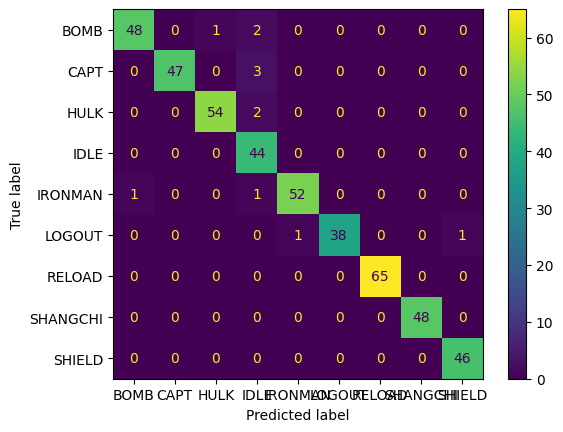

In [78]:
true_labels = []
predicted_labels = []

print(len(test_loader))
inputs, lcheck = next(iter(test_loader))

# Print the shape of the input tensor
print("Input size:", inputs.size())

for inputs, labels in test_loader:
    outputs, _, _, three = model(inputs)
    _, predicted = torch.max(outputs, 1)
    true_labels.extend(labels.numpy())
    predicted_labels.extend(predicted.numpy())
    print(inputs[0])
    print(three[0])
    print(predicted_labels[0])
    print(true_labels[0])

true_labels = np.array(true_labels)
predicted_labels = np.array(predicted_labels)

conf_matrix = confusion_matrix(true_labels, predicted_labels)

print("Confusion Matrix:")
print(conf_matrix)
cm_display = ConfusionMatrixDisplay(conf_matrix, display_labels = ["BOMB", "CAPT","HULK", "IDLE", "IRONMAN", "LOGOUT","RELOAD", "SHANGCHI", "SHIELD"])
cm_display.plot()
plt.show()

print(test_loader)

In [ ]:
ll = [0.3046, 0.7193, 0.6704, 0.3721, 0.2357, 0.0187, 0.8623, 0.1067, 0.4780,
        0.4136, 0.2530, 0.3043, 0.5344, 0.4796, 0.1054, 0.4009, 0.1240, 0.1330,
        0.2945, 0.5003, 0.5310, 0.2218, 0.4113, 0.0317, 0.3493, 0.2564, 0.2690,
        0.4048, 0.6598, 0.6581, 0.3819, 0.4045, 0.0438, 0.6704, 0.6471, 0.4382,
        0.4396, 0.7876, 0.7877, 0.3589, 0.4158, 0.0275, 0.7618, 0.3729, 0.6276,
        0.2239, 0.4045, 0.4384, 0.2986, 0.2973, 0.1271, 0.6328, 0.0450, 0.2286]
tensor2 = torch.Tensor([ll, ll,ll, ll,ll, ll,ll, ll,ll, ll,ll, ll,ll, ll,ll, ll, ll, ll,ll, ll,ll, ll,ll, ll,ll, ll,ll, ll,ll, ll,ll, ll])

output, one, two, three = model(tensor2)
print(f"output: {output}")
print(f"one: {one}")
print(f"two: {two}")
print(f"three: {three}")

output: tensor([[9.9657e-01, 2.6038e-12, 4.8965e-04, 2.5179e-09, 1.3976e-09, 4.9573e-11,
         2.9410e-03, 1.7339e-13, 4.7363e-09],
        [9.9657e-01, 2.6038e-12, 4.8965e-04, 2.5179e-09, 1.3976e-09, 4.9573e-11,
         2.9410e-03, 1.7339e-13, 4.7363e-09],
        [9.9657e-01, 2.6038e-12, 4.8965e-04, 2.5179e-09, 1.3976e-09, 4.9573e-11,
         2.9410e-03, 1.7339e-13, 4.7363e-09],
        [9.9657e-01, 2.6038e-12, 4.8965e-04, 2.5179e-09, 1.3976e-09, 4.9573e-11,
         2.9410e-03, 1.7339e-13, 4.7363e-09],
        [9.9657e-01, 2.6038e-12, 4.8965e-04, 2.5179e-09, 1.3976e-09, 4.9573e-11,
         2.9410e-03, 1.7339e-13, 4.7363e-09],
        [9.9657e-01, 2.6038e-12, 4.8965e-04, 2.5179e-09, 1.3976e-09, 4.9573e-11,
         2.9410e-03, 1.7339e-13, 4.7363e-09],
        [9.9657e-01, 2.6038e-12, 4.8965e-04, 2.5179e-09, 1.3976e-09, 4.9573e-11,
         2.9410e-03, 1.7339e-13, 4.7363e-09],
        [9.9657e-01, 2.6038e-12, 4.8965e-04, 2.5179e-09, 1.3976e-09, 4.9573e-11,
         2.9410e-03, 1

In [ ]:
torch.save(model.state_dict(), 'model_weights_biases.pth')

In [ ]:
model_weights_path = 'model_weights_biases.pth'
model.load_state_dict(torch.load(model_weights_path))
txt_path = 'model_parameters.txt'
all_weights_and_biases = []
with open(txt_path, 'w') as f:
    for name, param in model.named_parameters():
        # f.write(f"{name}:\n")
        print(name)
        flattened_param = param.flatten().tolist()  # Flatten the parameter tensor
        all_weights_and_biases += flattened_param
        # f.write(f"{flattened_param}\n\n")
        print(len(flattened_param))
    multiplied_list = [int(element * 10000000) for element in all_weights_and_biases]
    f.write(f"{multiplied_list}")
 

print(len(all_weights_and_biases))

print("Model parameters saved to:", txt_path)

fc1.weight
1944
fc1.bias
36
fc2.weight
648
fc2.bias
18
fc3.weight
162
fc3.bias
9
2817
Model parameters saved to: model_parameters.txt


In [111]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
from scipy.stats import skew, kurtosis
import os
import pickle

model_weights_path = 'model_weights_biases.pth'
model = Sample_NN()
model.load_state_dict(torch.load(model_weights_path))
model.eval()

# Load scaler and min-max scaler
with open('./scaler.pkl', 'rb') as scaler_file:
    scaler = pickle.load(scaler_file)

with open('./min_max_scaler.pkl', 'rb') as min_max_scaler_file:
    min_max_scaler = pickle.load(min_max_scaler_file)


# Function to process a CSV file
def process_csv(file_path):
    df = pd.read_csv(file_path)
    processed_features = []
    for i in range(6):
        column_list = df.iloc[:, i].tolist()
        t_mean = np.mean(column_list)
        t_std_deviation = np.std(column_list)
        t_rms = np.sqrt(np.mean(np.square(column_list)))
        t_skew = skew(column_list)
        t_kurtosis = kurtosis(column_list)
        t_50_q = np.percentile(column_list, 50)
        freq_domain = np.fft.rfft(column_list)
        f_mean = abs(np.mean(freq_domain))
        f_max = abs(max(freq_domain))
        f_total_power = np.sum(np.abs(freq_domain) ** 2)
        processed_features +=  [t_mean, t_std_deviation, t_rms, t_skew,t_50_q,t_kurtosis, f_mean, f_max, f_total_power]

    processed_features = np.array(processed_features).reshape(1,-1)
    scaled_test_point = scaler.transform(processed_features)
    normalized_test_point = min_max_scaler.transform(scaled_test_point)
    check = normalized_test_point.tolist()[0][0]

    return normalized_test_point

encoding = {
    "BOMB": 0, "CAPT": 1, "HULK": 2, "IDLE": 3, "IRONMAN": 4, "LOGOUT": 5, "RELOAD": 6, "SHANGCHI": 7,"SHIELD": 8
}

# Run the model on all CSV files in the directory "./all"
correct = 0 
wrong = 0

for file_name in os.listdir('./all_zip/all'):
    sub = file_name
    sub = re.sub(r'\d+', '', sub)
    sub = re.sub(r'\.csv', '', sub)
    true_label = encoding[sub]
    if file_name.endswith('.csv'):
        normalized_test_point = process_csv(os.path.join('./all_zip/all', file_name))

        with torch.no_grad():
            output, one, two, three = model(torch.Tensor(normalized_test_point))
            #if val:
                #print("output", output)
                #print("one",one)
                #print("two", two)
                #print("three", three)
            _, predicted_index = torch.max(output, 1)
            predicted_index = predicted_index.item()
            print("predicted_index: ", predicted_index, "| true_label: ", true_label, "|" ,sub)
            if predicted_index == true_label:
                correct += 1
            else:
                wrong += 1

print(correct)
print(wrong)
print(correct+ wrong)

predicted_index:  3 | true_label:  0 | BOMB
predicted_index:  0 | true_label:  0 | BOMB
predicted_index:  0 | true_label:  0 | BOMB
predicted_index:  0 | true_label:  0 | BOMB
predicted_index:  0 | true_label:  0 | BOMB
predicted_index:  0 | true_label:  0 | BOMB
predicted_index:  0 | true_label:  0 | BOMB
predicted_index:  0 | true_label:  0 | BOMB
predicted_index:  0 | true_label:  0 | BOMB
predicted_index:  0 | true_label:  0 | BOMB
predicted_index:  0 | true_label:  0 | BOMB
predicted_index:  0 | true_label:  0 | BOMB
predicted_index:  0 | true_label:  0 | BOMB
predicted_index:  0 | true_label:  0 | BOMB
predicted_index:  0 | true_label:  0 | BOMB
predicted_index:  3 | true_label:  0 | BOMB
predicted_index:  0 | true_label:  0 | BOMB
predicted_index:  0 | true_label:  0 | BOMB
predicted_index:  0 | true_label:  0 | BOMB
predicted_index:  0 | true_label:  0 | BOMB
predicted_index:  0 | true_label:  0 | BOMB
predicted_index:  0 | true_label:  0 | BOMB
predicted_index:  0 | true_label

In [110]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
from scipy.stats import skew, kurtosis
import os
import pickle

model_weights_path = 'model_weights_biases.pth'
model = Sample_NN()
model.load_state_dict(torch.load(model_weights_path))
model.eval()

# Load scaler and min-max scaler
with open('./scaler.pkl', 'rb') as scaler_file:
    scaler = pickle.load(scaler_file)

with open('./min_max_scaler.pkl', 'rb') as min_max_scaler_file:
    min_max_scaler = pickle.load(min_max_scaler_file)


# Function to process a CSV file
def process_csv(file_path):
    df = pd.read_csv(file_path)
    processed_features = []
    for i in range(6):
        column_list = df.iloc[:, i].tolist()
        t_mean = np.mean(column_list)
        t_std_deviation = np.std(column_list)
        t_rms = np.sqrt(np.mean(np.square(column_list)))
        t_skew = skew(column_list)
        t_kurtosis = kurtosis(column_list)
        t_50_q = np.percentile(column_list, 50)
        freq_domain = np.fft.rfft(column_list)
        f_mean = abs(np.mean(freq_domain))
        f_max = abs(max(freq_domain))
        f_total_power = np.sum(np.abs(freq_domain) ** 2)
        processed_features +=  [t_mean, t_std_deviation, t_rms, t_skew,t_50_q,t_kurtosis, f_mean, f_max, f_total_power]

    processed_features = np.array(processed_features).reshape(1,-1)
    scaled_test_point = scaler.transform(processed_features)
    normalized_test_point = min_max_scaler.transform(scaled_test_point)
    check = normalized_test_point.tolist()[0][0]

    return normalized_test_point

encoding = {
    "BOMB": 0, "CAPT": 1, "HULK": 2, "IDLE": 3, "IRONMAN": 4, "LOGOUT": 5, "RELOAD": 6, "SHANGCHI": 7,"SHIELD": 8
}

# Run the model on all CSV files in the directory "./all"
correct = 0 
wrong = 0

log_file = open("checkpreprocess.txt", "w")
file_path = "checkpreprocess2.csv"
import csv

# Write the list to a CSV file
with open(file_path, "w", newline="") as csvfile:
    writer = csv.writer(csvfile)

    for file_name in os.listdir('./all_zip/all'):
        if file_name == "BOMB2.csv":
        #if 'BOMB' in file_name:
            normalized_test_point = process_csv(os.path.join('./all_zip/all', file_name))
            writer.writerow(normalized_test_point[0])





print(correct)
print(wrong)
print(correct+ wrong)

0
0
0
